**Author**: Felipe Matheus  
**Start Date**: 06/05/2026  
**End Date**: 19/06/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm
from autogluon.tabular import TabularPredictor


module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from src.metrics.Evaluation import Evaluation
from src.DataLoader import LoaderHelper

from config.Variables import Variables

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
modl = Modeling()
evla = Evaluation()
varv = Variables()
load = LoaderHelper()


## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [24]:
# ---- Experiment settings ----
TAG = "with-grain-size"
SCHEMA_DATE = "080626"

# ---- Paths ----
FILE_NAME = "dataset_annealing_iacs.csv"
FILE_NAME_SCHEMA_DATA = "schema_annealing_essays_{}.csv".format(SCHEMA_DATE)
FILE_NAME_VALIDATION_DATA = "Experimental Results Annealing V2 - CompiledResults.csv"

PROCESS = "annealing_iacs"

# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(varv.PATHS.models, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "iacs_final"
FEATURES = ["purity", "iacs", "grain_size", "grain_size_final", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "medium_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of sigma2_aleat as fraction of Var(y), in case of predictions as "100% sure" it still adds  small variance
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
USE_SHARED_FOLDS = False           # same fold_id column on both engines
FOLD_SEED = 42

# ---- Physical constraints (inference-time) ----
Y_MAX = 105.0                     # physical ceiling for %IACS


# 2. Data

## 2.1 Schema data

In [8]:
# # Schema dataset. Mark essay rows EXPLICITLY (used later for weight_col).
# df_raw_schema = pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME_SCHEMA_DATA))
# df_schema = df_raw_schema[FEATURES + [TARGET]].dropna()
# df_schema["is_essay"] = True
# df_schema


## 2.2 Literature data

In [7]:
# Raw CSV.
df_raw = pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME))
df_raw

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final
0,Cu,99.98,320,97,473,30,~500,100
1,Cu,99.98,320,97,523,600,~800,100
2,Cu,99.98,320,97,573,120,~900,103
3,Cu,99.98,320,96,473,30,~500,99
4,Cu,99.98,320,95,523,600,~800,98
...,...,...,...,...,...,...,...,...
126,Al–0.5Mg–0.5Si (wt%),~99.7,250,58,623,60,~2000,~67.4
127,Al–0.5Mg–0.5Si (wt%),~99.7,250,58,623,120,~2500,~68.2
128,Al–Mn–Mg alloy,~99.5,250,~35,423,60,~400,~38
129,Al–Mn–Mg alloy,~99.5,250,~35,523,60,~800,~43


In [9]:
# Cast to float, label material elements, mark rows where ratios are valid.
df_float = proc.df_to_float(
    df_raw, drop_cols=["DOI"], ignore_columns=["material"]
)
df_labeled = feng.label_element(df_float).drop_duplicates()
df_with_masks = feng.add_ratio_mask_column(
    feng.add_ratio_mask_column(df_labeled, "grain_size"),
    "iacs",
)

# Keep only copper rows and the schema columns.
mask_cu = df_with_masks.has_Cu == True
df_lit = df_with_masks[mask_cu]
df_lit = df_lit[FEATURES + [TARGET]]
df_lit["is_essay"] = False

assert df_lit[FEATURES + [TARGET]].isna().sum().sum() == 0, "NaNs in inputs"
print(f"Dataset: {df_lit.shape}")
df_lit.head()


Dataset: (87, 8)


,purity,iacs,grain_size,grain_size_final,temperature,time,iacs_final,is_essay
0,99.98,97.0,320.0,500.0,473.0,30.0,100.0,False
1,99.98,97.0,320.0,800.0,523.0,600.0,100.0,False
2,99.98,97.0,320.0,900.0,573.0,120.0,103.0,False
3,99.98,96.0,320.0,500.0,473.0,30.0,99.0,False
4,99.98,95.0,320.0,800.0,523.0,600.0,98.0,False


## 2.3 Concat dataset

In [10]:
# df = pd.concat([df_schema, df_lit], ignore_index=True)

# df["weight_col"] = np.where(df["is_essay"], WEIGHT_ON_ESSAY_ROWS, 1.0)

# # Optional shared fold column: the SAME partition is passed to AutoGluon
# # (groups=) and H2O (fold_column=) so OOF comparisons use identical folds.
# if USE_SHARED_FOLDS:
#     df = feng.add_stratified_fold_column(
#         df, n_folds=NUM_BAG_FOLDS_A, seed=FOLD_SEED,
#     )

df = df_lit.copy()
df


,purity,iacs,grain_size,grain_size_final,temperature,time,iacs_final,is_essay
0,99.98,97.0,320.0,500.0,473.0,30.0,100.0,False
1,99.98,97.0,320.0,800.0,523.0,600.0,100.0,False
2,99.98,97.0,320.0,900.0,573.0,120.0,103.0,False
3,99.98,96.0,320.0,500.0,473.0,30.0,99.0,False
4,99.98,95.0,320.0,800.0,523.0,600.0,98.0,False
...,...,...,...,...,...,...,...,...
99,99.00,88.0,180.0,450.0,673.0,30.0,97.0,False
100,99.00,87.0,190.0,270.0,473.0,30.0,89.0,False
101,99.00,87.0,190.0,350.0,573.0,30.0,92.0,False
102,99.00,87.0,190.0,480.0,673.0,30.0,95.0,False


## 2.4 Validation data

In [54]:
# ---- Validation data ----
# df_val = proc.load_validation_data_chimie_paris(
#     path=os.path.join(varv.PATHS.data_processed, FILE_NAME_VALIDATION_DATA)
# )
df_val = df.sample(20)
df_val

,purity,iacs,grain_size,grain_size_final,temperature,time,iacs_final,is_essay
82,99.90,70.0,140.0,480.0,673.0,60.0,78.0,False
88,99.30,78.0,200.0,800.0,623.0,60.0,92.0,False
35,99.80,50.0,150.0,500.0,723.0,60.0,70.0,False
63,99.90,90.0,180.0,320.0,473.0,60.0,94.0,False
27,99.90,72.0,450.0,550.0,673.0,60.0,79.0,False
100,99.00,87.0,190.0,270.0,473.0,30.0,89.0,False
69,99.90,85.0,220.0,350.0,473.0,60.0,90.0,False
2,99.98,97.0,320.0,900.0,573.0,120.0,103.0,False
112,80.00,80.0,200.0,800.0,773.0,60.0,80.0,False
12,99.80,81.0,200.0,230.0,373.0,30.0,82.0,False


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [15]:
df.head(10)

,purity,iacs,grain_size,grain_size_final,temperature,time,iacs_final,is_essay
0,99.98,97.0,320.0,500.0,473.0,30.0,100.0,False
1,99.98,97.0,320.0,800.0,523.0,600.0,100.0,False
2,99.98,97.0,320.0,900.0,573.0,120.0,103.0,False
3,99.98,96.0,320.0,500.0,473.0,30.0,99.0,False
4,99.98,95.0,320.0,800.0,523.0,600.0,98.0,False
5,99.98,94.0,320.0,800.0,523.0,600.0,97.0,False
6,99.98,92.0,320.0,500.0,473.0,30.0,95.0,False
7,99.50,57.0,200.0,450.0,400.0,90.0,89.0,False
8,99.50,57.0,200.0,850.0,673.0,90.0,92.0,False
9,99.80,55.0,200.0,230.0,373.0,30.0,60.0,False


In [19]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    # groups="fold_id" if USE_SHARED_FOLDS else None,
    # sample_weight="weight_col",
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       13.38 GB / 31.57 GB (42.4%)
Disk Space Avail:   732.25 GB / 932.08 GB (78.6%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\with-grain-size\model_a"
Train Data Rows:    87
Train Data Columns: 6
Label Column:       iacs_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (105.0, 48.0, 88.01839, 11.9712)
	If 'regression' is not t

In [20]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-4.009306,root_mean_squared_error,0.117357,11.314514,0.000000,0.005257,2,True,10
1,ExtraTreesMSE_BAG_L1,-4.194145,root_mean_squared_error,0.047422,0.375760,0.047422,0.375760,1,True,5
2,RandomForestMSE_BAG_L1,-4.234709,root_mean_squared_error,0.032647,0.738178,0.032647,0.738178,1,True,3
3,NeuralNetTorch_BAG_L1,-4.434106,root_mean_squared_error,0.037289,10.195319,0.037289,10.195319,1,True,8
4,CatBoost_BAG_L1,-4.829956,root_mean_squared_error,0.005323,7.193360,0.005323,7.193360,1,True,4
5,XGBoost_BAG_L1,-4.993147,root_mean_squared_error,0.012488,0.616514,0.012488,0.616514,1,True,7
6,LightGBMLarge_BAG_L1,-5.179514,root_mean_squared_error,0.020160,2.459714,0.020160,2.459714,1,True,9
7,NeuralNetFastAI_BAG_L1,-5.520183,root_mean_squared_error,0.054826,8.130560,0.054826,8.130560,1,True,6
8,LightGBMXT_BAG_L1,-6.801076,root_mean_squared_error,0.003000,0.531770,0.003000,0.531770,1,True,1
9,LightGBM_BAG_L1,-6.867824,root_mean_squared_error,0.000000,1.157058,0.000000,1.157058,1,True,2


In [21]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-4.009306,root_mean_squared_error,0.117357,11.314514,0.000000,0.005257,2,True,10
1,ExtraTreesMSE_BAG_L1,-4.194145,root_mean_squared_error,0.047422,0.375760,0.047422,0.375760,1,True,5
2,RandomForestMSE_BAG_L1,-4.234709,root_mean_squared_error,0.032647,0.738178,0.032647,0.738178,1,True,3
3,NeuralNetTorch_BAG_L1,-4.434106,root_mean_squared_error,0.037289,10.195319,0.037289,10.195319,1,True,8
4,CatBoost_BAG_L1,-4.829956,root_mean_squared_error,0.005323,7.193360,0.005323,7.193360,1,True,4
5,XGBoost_BAG_L1,-4.993147,root_mean_squared_error,0.012488,0.616514,0.012488,0.616514,1,True,7
6,LightGBMLarge_BAG_L1,-5.179514,root_mean_squared_error,0.020160,2.459714,0.020160,2.459714,1,True,9
7,NeuralNetFastAI_BAG_L1,-5.520183,root_mean_squared_error,0.054826,8.130560,0.054826,8.130560,1,True,6
8,LightGBMXT_BAG_L1,-6.801076,root_mean_squared_error,0.003000,0.531770,0.003000,0.531770,1,True,1
9,LightGBM_BAG_L1,-6.867824,root_mean_squared_error,0.000000,1.157058,0.000000,1.157058,1,True,2


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [27]:
import h2o
from h2o.automl import H2OAutoML

h2o.init(nthreads=-1, max_mem_size="4G")

h2o_cols = FEATURES + [TARGET]
if USE_SHARED_FOLDS:
    h2o_cols.append("fold_id")
train_h2o = h2o.H2OFrame(df[h2o_cols])
train_h2o[TARGET] = train_h2o[TARGET].asnumeric()
if USE_SHARED_FOLDS:
    # fold_column must be categorical on the H2O side.
    train_h2o["fold_id"] = train_h2o["fold_id"].asfactor()

aml_kwargs = dict(
    max_runtime_secs=TIME_LIMIT_A,
    keep_cross_validation_predictions=True,
    exclude_algos=["DeepLearning"],
    sort_metric="RMSE",
    seed=42,
)
if not USE_SHARED_FOLDS:
    aml_kwargs["nfolds"] = NUM_BAG_FOLDS_A  # nfolds is ignored/conflicting with fold_column

aml_h2o = H2OAutoML(**aml_kwargs)

train_kwargs = dict(x=FEATURES, y=TARGET, training_frame=train_h2o)
                    # weights_column="weight_col")
if USE_SHARED_FOLDS:
    train_kwargs["fold_column"] = "fold_id"

aml_h2o.train(**train_kwargs)

aml_h2o.leaderboard.head(10)


Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,3 hours 4 mins
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,4 months and 3 days
H2O_cluster_name:,H2O_from_python_fmfoa_6ybb2d
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.973 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
16:58:47.312: AutoML: XGBoost is not available; skipping it.
16:58:47.678: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 87.0.

██████████████████████████████████████████████████████████████| (done) 100%


model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_grid_1_AutoML_2_20260715_165847_model_64,3.4292,11.7594,1.92438,0.0442698,11.7594
StackedEnsemble_BestOfFamily_3_AutoML_2_20260715_165847,3.49825,12.2378,1.94589,0.0450806,12.2378
StackedEnsemble_BestOfFamily_5_AutoML_2_20260715_165847,3.61895,13.0968,2.05225,0.0469984,13.0968
GBM_grid_1_AutoML_2_20260715_165847_model_290,3.70281,13.7108,2.13711,0.0473948,13.7108
GBM_grid_1_AutoML_2_20260715_165847_model_561,3.73019,13.9143,2.00025,0.0481856,13.9143
GBM_grid_1_AutoML_2_20260715_165847_model_703,3.73798,13.9725,2.09467,0.0481599,13.9725
GBM_grid_1_AutoML_2_20260715_165847_model_727,3.74069,13.9928,2.23157,0.0482731,13.9928
GBM_grid_1_AutoML_2_20260715_165847_model_584,3.76237,14.1554,2.23026,0.0485784,14.1554
GBM_grid_1_AutoML_2_20260715_165847_model_166,3.76891,14.2047,2.11453,0.0485239,14.2047
GBM_grid_1_AutoML_2_20260715_165847_model_600,3.78629,14.336,2.10683,0.0489004,14.336


In [28]:
# NOTE: the previous cell here compared AutoGluon's `score_val` against
# H2O's xval RMSE. That comparison is incoherent when sample weights are
# active: H2O's xval RMSE is WEIGHTED by weights_column, while AutoGluon's
# score_val is UNWEIGHTED unless weight_evaluation=True. The fair,
# like-for-like comparison (unweighted metrics on OOF predictions of both
# engines, same y_true, same folds when USE_SHARED_FOLDS) is done in
# Section 10 ("OOF metrics: AutoGluon vs H2O").
print("See Section 10 for the coherent OOF-vs-OOF comparison.")


See Section 10 for the coherent OOF-vs-OOF comparison.


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [29]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = df[TARGET] - mu_oof
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(87,)  any NaN? False


## 4.1 fast check on big residuals

In [30]:
residuals_oof.head(10)

0     0.673645
1    -0.242058
2     1.582039
3     0.058807
4    -0.589417
5    -1.008308
6    -2.315201
7    15.412445
8     7.457520
9   -19.403282
Name: iacs_final, dtype: float64

In [31]:
df[residuals_oof.abs() > 2]

,purity,iacs,grain_size,grain_size_final,temperature,time,iacs_final,is_essay
6,99.98,92.0,320.0,500.0,473.0,30.0,95.0,False
7,99.50,57.0,200.0,450.0,400.0,90.0,89.0,False
8,99.50,57.0,200.0,850.0,673.0,90.0,92.0,False
9,99.80,55.0,200.0,230.0,373.0,30.0,60.0,False
10,99.80,55.0,200.0,300.0,473.0,30.0,80.0,False
11,99.80,55.0,200.0,350.0,573.0,30.0,85.0,False
14,99.80,81.0,200.0,350.0,573.0,30.0,85.0,False
19,99.50,36.0,200.0,1000.0,773.0,30.0,85.0,False
20,99.90,46.0,150.0,500.0,673.0,60.0,70.0,False
22,99.90,46.0,150.0,800.0,773.0,60.0,85.0,False


## 4.2 Recovering weights 

In [32]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (9, 87)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1']


In [33]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000004  (OK)

Non-zero weights:
  RandomForestMSE_BAG_L1          0.3158
  ExtraTreesMSE_BAG_L1            0.3158
  NeuralNetTorch_BAG_L1           0.3684


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [34]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

mu_diffs = np.abs(mu_recomputed - mu_oof)
mu_diffs.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof):.4f}")
# print(f"  max    = {sigma2_epist_oof.max():.4f}")

count    8.700000e+01
mean     1.931123e-06
std      1.074758e-06
min      1.709211e-08
25%      1.148461e-06
50%      1.684727e-06
75%      2.884121e-06
max      4.104824e-06
Name: iacs_final, dtype: float64

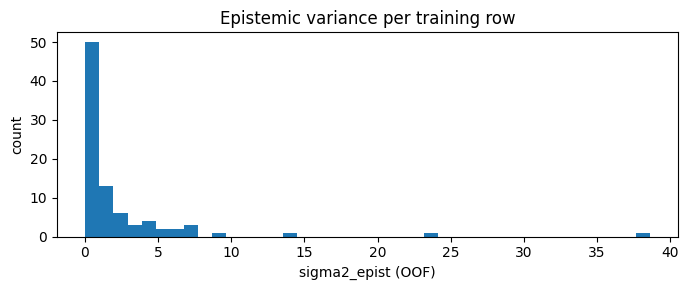

In [35]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

In [36]:
mu_recomputed_lin, sigma2_epist_oof_lin = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

mu_diffs_lin = np.abs(mu_recomputed_lin - mu_oof)
mu_diffs_lin.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
# print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

count    87.000000
mean      0.947468
std       1.287222
min       0.009918
25%       0.300262
50%       0.575508
75%       1.070396
max       7.648708
Name: iacs_final, dtype: float64

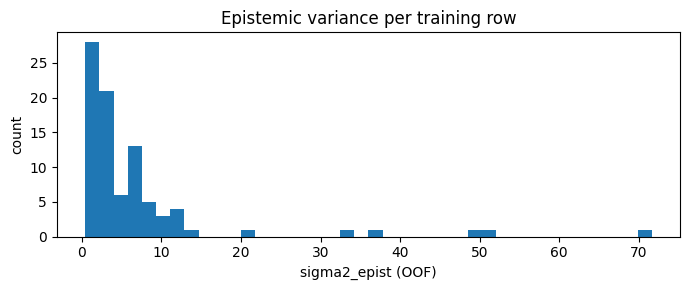

In [37]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Section 5 Conclusion

Linear shows way more errors between the recomputed values. Weighted one is corrected.

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [38]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 87
  n_truncated          = 37
  pct_truncated        = 42.52873563218391
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 376.0495135832743
  r_tilde_sq_mean      = 14.785481791256522
  r_tilde_sq_median    = 0.18106084067851388


In [39]:
r_tilde_sq

array([0.00000000e+00, 0.00000000e+00, 2.07389327e+00, 0.00000000e+00,
       1.81060841e-01, 9.70800213e-01, 4.91603238e+00, 2.36068474e+02,
       5.34599519e+01, 3.76049514e+02, 4.23697623e+01, 4.85533031e+01,
       0.00000000e+00, 0.00000000e+00, 5.05018519e+00, 0.00000000e+00,
       6.16724450e+00, 0.00000000e+00, 1.71422599e+01, 1.45229718e+01,
       1.40697444e+01, 1.21054897e+01, 7.27632656e+00, 3.62791490e+01,
       0.00000000e+00, 0.00000000e+00, 3.41631476e+01, 1.45814632e+01,
       0.00000000e+00, 4.94252982e+01, 5.68021895e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.21889221e-01, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.25994110e+00, 7.83137120e-01, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.34651429e+00, 5.16663848e-01,
       4.53165909e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       2.29135937e-02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [40]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       11.45 GB / 31.57 GB (36.3%)
Disk Space Avail:   732.08 GB / 932.08 GB (78.5%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\with-grain-size\model_b"
Train Data Rows:    87
Train Data Columns: 6
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (5.929720822441302, -13.815510557964274, -5.28983, 7.59

In [41]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-6.875832,root_mean_squared_error,0.064465,8.611082,0.000000,0.008524,2,True,10
1,NeuralNetFastAI_BAG_L1,-7.050664,root_mean_squared_error,0.052416,7.581054,0.052416,7.581054,1,True,6
2,XGBoost_BAG_L1,-7.188096,root_mean_squared_error,0.012049,1.021505,0.012049,1.021505,1,True,7
3,CatBoost_BAG_L1,-7.300616,root_mean_squared_error,0.004339,1.288001,0.004339,1.288001,1,True,4
4,LightGBMLarge_BAG_L1,-7.312106,root_mean_squared_error,0.003093,1.094157,0.003093,1.094157,1,True,9
5,LightGBMXT_BAG_L1,-7.392373,root_mean_squared_error,0.002534,0.886205,0.002534,0.886205,1,True,1
6,NeuralNetTorch_BAG_L1,-7.433815,root_mean_squared_error,0.031185,6.337383,0.031185,6.337383,1,True,8
7,LightGBM_BAG_L1,-7.492833,root_mean_squared_error,0.006600,1.061588,0.006600,1.061588,1,True,2
8,ExtraTreesMSE_BAG_L1,-7.528202,root_mean_squared_error,0.035052,0.382273,0.035052,0.382273,1,True,5
9,RandomForestMSE_BAG_L1,-7.763259,root_mean_squared_error,0.065919,0.416151,0.065919,0.416151,1,True,3


In [42]:
predictor_b.predict_oof()  

0     -7.806856
1     -4.604598
2     -7.083327
3     -5.887090
4     -5.338476
         ...   
99    -5.402243
100   -8.733450
101   -5.788608
102   -4.318677
112    2.877778
Name: log_r_tilde_sq, Length: 87, dtype: float32

In [43]:
df_lado_a_lado = pd.DataFrame({
    "residual_oof": residuals_oof,
    "predict_random_error": predictor_b.predict_oof()  , 
    "epistemic_error": sigma2_epist_oof,
    "iacs": df["iacs"],
    "iacs_final": df[TARGET]
}) 
df_lado_a_lado

,residual_oof,predict_random_error,epistemic_error,iacs,iacs_final
0,0.673645,-7.806856,0.896971,97.0,100.0
1,-0.242058,-4.604598,1.263311,97.0,100.0
2,1.582039,-7.083327,0.428954,97.0,103.0
3,0.058807,-5.887090,0.614388,96.0,99.0
4,-0.589417,-5.338476,0.166351,95.0,98.0
...,...,...,...,...,...
99,2.399162,-5.402243,0.094097,88.0,97.0
100,-0.935608,-8.733450,0.292982,87.0,89.0
101,-0.456169,-5.788608,0.852619,87.0,92.0
102,-0.504700,-4.318677,0.078752,87.0,95.0


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [44]:
df[TARGET].var()

np.float64(143.30965784549585)

Real coverage considering sigmas calculated so far

Build the predictive distribution. Not totally OOF cause model b is not generating OOF preds, we assume it's optimistic just a bit too small to be considered.


In [45]:
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
cal_before

=== Calibration BEFORE recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.505747,0.005747
1,0.80,0.712644,-0.087356
2,0.90,0.770115,-0.129885
3,0.95,0.827586,-0.122414


Fit a scalar recalibration factor to pull coverage using α=0.9 as nominal reference


In [46]:
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
cal_after

Recalibration scalar c = 2.0451

=== Calibration AFTER recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.724138,0.224138
1,0.80,0.873563,0.073563
2,0.90,0.896552,-0.003448
3,0.95,0.919540,-0.030460


# 8.1 Validation Set Evaluation

Evaluate the freshly trained pair (A + B, with the recalibration $c$) on a
validation DataFrame.

`modl.predict_target` is target-agnostic: it accepts a DataFrame **or a dict**
and any AutoGluon predictor (IACS, UTS, Model B...), inferring the features
from the predictor when not given.

In [55]:
# ---- Validation set: df_schema (illustrative; in-sample, see caveat) ----
# df_val = df_schema.copy()

# Full calibrated predictive distribution on the validation set.
preds_val = modl.predict_with_uncertainty(
    X=df_val, # df_schema.copy()
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,
)

val_metrics = evla.metrics_on_dataframe(
    df=df_val, #df_schema.copy()
    target=TARGET,
    mu=preds_val["mu"].to_numpy(),
    sigma=preds_val["sigma_total"].to_numpy(),
    alphas=CALIBRATION_ALPHAS,
)
print("=== Validation metrics (df_schema) ===")
print({k: round(v, 4) for k, v in val_metrics.items() if k != "coverage"})
print("coverage:", {a: round(c, 3) for a, c in val_metrics["coverage"].items()})

=== Validation metrics (df_schema) ===
{'rmse': 1.2326, 'mae': 0.745, 'mape': 0.9451, 'r2': 0.9894}
coverage: {0.5: 0.9, 0.8: 0.95, 0.9: 1.0, 0.95: 1.0}


In [56]:
val_metrics

{'rmse': 1.232623680962092,
 'mae': 0.7449686940962394,
 'mape': 0.9450902609897356,
 'r2': 0.989389195203097,
 'coverage': {0.5: 0.9, 0.8: 0.95, 0.9: 1.0, 0.95: 1.0}}

In [57]:
df_val

,purity,iacs,grain_size,grain_size_final,temperature,time,iacs_final,is_essay
82,99.90,70.0,140.0,480.0,673.0,60.0,78.0,False
88,99.30,78.0,200.0,800.0,623.0,60.0,92.0,False
35,99.80,50.0,150.0,500.0,723.0,60.0,70.0,False
63,99.90,90.0,180.0,320.0,473.0,60.0,94.0,False
27,99.90,72.0,450.0,550.0,673.0,60.0,79.0,False
100,99.00,87.0,190.0,270.0,473.0,30.0,89.0,False
69,99.90,85.0,220.0,350.0,473.0,60.0,90.0,False
2,99.98,97.0,320.0,900.0,573.0,120.0,103.0,False
112,80.00,80.0,200.0,800.0,773.0,60.0,80.0,False
12,99.80,81.0,200.0,230.0,373.0,30.0,82.0,False


In [58]:
preds_val

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,77.955231,0.270374,1.433097,7.124588,2.669192,77.955231,1.0,77.955231,2.669192,0.000000e+00
1,91.382233,0.048301,1.433097,6.195790,2.489134,91.382233,1.0,91.382233,2.489134,2.238977e-08
2,71.393669,0.120854,1.433097,6.499235,2.549360,71.393669,1.0,71.393669,2.549360,0.000000e+00
3,93.523738,0.031214,1.433097,6.124328,2.474738,93.523735,1.0,93.523717,2.474689,1.764401e-06
4,81.663559,0.090732,1.433097,6.373254,2.524530,81.663559,1.0,81.663559,2.524530,0.000000e+00
5,89.243687,0.129742,1.433097,6.536409,2.556640,89.243690,1.0,89.243687,2.556640,3.571272e-10
6,90.000499,0.019634,1.433097,6.075895,2.464933,90.000496,1.0,90.000499,2.464933,5.818924e-10
7,102.120385,0.314857,1.433097,7.310636,2.703819,102.120384,1.0,101.406177,2.178049,1.434339e-01
8,84.089553,0.151983,1.433097,6.629431,2.574768,84.089554,1.0,84.089553,2.574768,2.220446e-16
9,81.241476,0.810060,1.433097,9.381771,3.062968,81.241478,1.0,81.241476,3.062968,4.329870e-15


In [59]:
# ---- Target-agnostic point prediction from a plain dict ----
single = modl.predict_target(
    predictor_a,
    {"purity": 99.9, "iacs": 88.26,
     "grain_size": 200, "grain_size_final": 400,
    "temperature": 623.0, "time": 60.0},
)
print(f"Predicted {TARGET}: {single[0]:.3f}")

Predicted iacs_final: 94.796


# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [60]:
df.head(5)

,purity,iacs,grain_size,grain_size_final,temperature,time,iacs_final,is_essay
0,99.98,97.0,320.0,500.0,473.0,30.0,100.0,False
1,99.98,97.0,320.0,800.0,523.0,600.0,100.0,False
2,99.98,97.0,320.0,900.0,573.0,120.0,103.0,False
3,99.98,96.0,320.0,500.0,473.0,30.0,99.0,False
4,99.98,95.0,320.0,800.0,523.0,600.0,98.0,False


In [61]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = modl.fit_ood_reference(df, features=FEATURES)

preds = modl.predict_with_uncertainty(
    X=df_val.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,          # physical ceiling -> mu_trunc / sigma_trunc / p_above_max
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds


,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,77.955231,0.270374,1.433097,7.124588,2.669192,77.955231,1.0,77.955231,2.669192,0.000000e+00
1,91.382233,0.048301,1.433097,6.195790,2.489134,91.382233,1.0,91.382233,2.489134,2.238977e-08
2,71.393669,0.120854,1.433097,6.499235,2.549360,71.393669,1.0,71.393669,2.549360,0.000000e+00
3,93.523738,0.031214,1.433097,6.124328,2.474738,93.523735,1.0,93.523717,2.474689,1.764401e-06
4,81.663559,0.090732,1.433097,6.373254,2.524530,81.663559,1.0,81.663559,2.524530,0.000000e+00


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [63]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "y_max": Y_MAX,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")


Saved to: ../../models/annealing_iacs\with-grain-size\artifacts.pkl


In [64]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "SCHEMA_DATE": SCHEMA_DATE,
    "varv.PATHS.data_raw": varv.PATHS.data_raw,
    "varv.PATHS.models": varv.PATHS.models,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
    "Y_MAX": Y_MAX,
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")


Saved to: ../../models/annealing_iacs\with-grain-size\global_config.txt


In [65]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
h2o_oof_preds = (
    aml_h2o.leader.cross_validation_holdout_predictions()
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


                         model      rmse       mae      mape        r2
0  AutoGluon (Model A, leader)  4.009306  2.295992  2.907262  0.886529
1          H2O AutoML (leader)  3.429196  1.924378  2.448436  0.916990


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Saved to: ../../models/annealing_iacs\with-grain-size


# 11. Load Artifacts & Predict (deployment simulation)

This section simulates a fresh process: it loads ONLY what was persisted in
Section 10 (`artifacts.pkl`) plus the two AutoGluon predictors from disk —
no variable from the training session above is reused. This is exactly what a
deployment script (or the MBC controller) would do. The same
`predict_with_uncertainty` call as Section 9 runs, but every ingredient
(`weights`, `recalibration_c`, `ood_ref`, `y_max`, ...) comes from the
reloaded artifacts, proving the persisted bundle is self-contained.

In [66]:

# ---- 1) Load the persisted artifact bundle (Section 10) ----
loaded_artifacts = load.load_pickle(EXPERIMENT_DIR, "artifacts.pkl")

# ---- 2) Reload both AutoGluon predictors from their TAG subfolders ----
predictor_a_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_a")
)
predictor_b_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_b")
)

print("Loaded artifacts keys:", list(loaded_artifacts.keys()))
print("Target:", loaded_artifacts["target"])
print("Features:", loaded_artifacts["features"])

Loaded artifacts keys: ['features', 'target', 'base_model_names', 'weights', 'variance_floor', 'recalibration_c', 'use_weighted_variance', 'calibration_before', 'calibration_after', 'y_max', 'ood_ref']
Target: iacs_final
Features: ['purity', 'iacs', 'grain_size', 'grain_size_final', 'temperature', 'time']


In [67]:
# ---- 3) Predict using ONLY the reloaded objects ----
# Build a small query frame (here: first rows of df, but in deployment this
# would be a brand-new candidate route from the controller).
X_query = df_val.head(5)

preds_loaded = modl.predict_with_uncertainty(
    X=X_query,
    predictor_a=predictor_a_loaded,
    predictor_b=predictor_b_loaded,
    weights=loaded_artifacts["weights"],
    model_names=loaded_artifacts["base_model_names"],
    features=loaded_artifacts["features"],
    variance_floor=loaded_artifacts["variance_floor"],
    recalibration_c=loaded_artifacts["recalibration_c"],
    use_weights=loaded_artifacts["use_weighted_variance"],
    y_max=loaded_artifacts["y_max"],
    ood_ref=loaded_artifacts["ood_ref"],
)
preds_loaded

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,77.955231,0.270374,1.433097,7.124588,2.669192,77.955231,1.0,77.955231,2.669192,0.000000e+00
1,91.382233,0.048301,1.433097,6.195790,2.489134,91.382233,1.0,91.382233,2.489134,2.238977e-08
2,71.393669,0.120854,1.433097,6.499235,2.549360,71.393669,1.0,71.393669,2.549360,0.000000e+00
3,93.523738,0.031214,1.433097,6.124328,2.474738,93.523735,1.0,93.523717,2.474689,1.764401e-06
4,81.663559,0.090732,1.433097,6.373254,2.524530,81.663559,1.0,81.663559,2.524530,0.000000e+00


In [70]:
# ---- 4) Target-agnostic quick prediction from a plain dict ----
# Works for any predictor/target via modl.predict_target (features inferred
# from the predictor when not passed explicitly).
single_loaded = modl.predict_target(
    predictor_a_loaded,
    {"purity": 99.9, "iacs": 88.26, "temperature": 623.0,
     "grain_size": 200, "grain_size_final": 250, "time": 60.0},
    features=loaded_artifacts["features"],
)
print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

Predicted iacs_final: 92.289


In [69]:
# ---- 5) Sanity check: reloaded predictions match the in-session ones ----
# (Section 9 computed `preds` on df.head(5) with the same ood_ref/c_opt.)
import numpy as np
if "preds" in dir():
    max_mu_diff = float(np.abs(preds["mu"].to_numpy()
                               - preds_loaded["mu"].to_numpy()).max())
    max_sigma_diff = float(np.abs(preds["sigma_total"].to_numpy()
                                  - preds_loaded["sigma_total"].to_numpy()).max())
    print(f"max |mu diff|    = {max_mu_diff:.2e}")
    print(f"max |sigma diff| = {max_sigma_diff:.2e}")
    print("OK: artifacts reproduce the in-session pipeline."
          if max(max_mu_diff, max_sigma_diff) < 1e-8
          else "WARNING: mismatch - check that Section 9 used the same ood_ref.")
else:
    print("Run Section 9 first to enable the sanity check.")

max |mu diff|    = 0.00e+00
max |sigma diff| = 0.00e+00
OK: artifacts reproduce the in-session pipeline.
